# RiMEA 16: Looped Ring Parameter Study

This notebook rebuilds the RiMEA 16 one-dimensional loop from scratch using the oval helper pattern from the JuPedSim `single-file` notebook. Agents are placed directly along the loop to avoid compaction from a dense spawn area, then routed through three repeating checkpoints.

We keep $v_0 = 1.2$ m/s fixed and compare three target density levels, `0.5`, `0.8`, and `1.5` 1/m, against the RiMEA 16 reference 10% and 90% percentile band stored in `scenarios/rimea16_percentile_reference.csv`.

In [1]:
from contextlib import redirect_stdout
import io

import matplotlib.pyplot as plt
import pandas as pd
import pedpy

from scenario_builders.rimea16_loop import (
    build_loop_geometry,
    build_loop_scenario,
    compute_density_speed_curve,
    compute_density_speed_samples,
    compute_lap_counts,
    load_reference_band,
    summarize_reference_fit,
)
from core.scenario import run_scenario

In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.edgecolor": "#444444",
        "axes.titleweight": "bold",
        "font.size": 11,
    }
)

DESIRED_SPEED = 1.2
PREVIEW_GEOMETRY = build_loop_geometry()
TRACK_LENGTH = PREVIEW_GEOMETRY.track_length
DENSITY_CASES = [
    {
        "label": "low density",
        "target_density_1pm": 0.5,
        "num_agents": max(2, round(TRACK_LENGTH * 0.5)),
        "color": "#4C72B0",
    },
    {
        "label": "medium density",
        "target_density_1pm": 0.8,
        "num_agents": max(2, round(TRACK_LENGTH * 0.8)),
        "color": "#55A868",
    },
    {
        "label": "high density",
        "target_density_1pm": 1.5,
        "num_agents": max(2, round(TRACK_LENGTH * 1.5)),
        "color": "#C44E52",
    },
]
PREVIEW_SCENARIO, _ = build_loop_scenario(
    label="rimea16-preview",
    desired_speed=DESIRED_SPEED,
    num_agents=DENSITY_CASES[-1]["num_agents"],
    spacing=TRACK_LENGTH / DENSITY_CASES[-1]["num_agents"],
)
REFERENCE = load_reference_band()

pd.DataFrame(DENSITY_CASES)

,label,target_density_1pm,num_agents,color
0,low density,0.5,13,#4C72B0
1,medium density,0.8,21,#55A868
2,high density,1.5,40,#C44E52


## Geometry Preview

The oval ring is built from an outer and inner boundary, while the agents start already distributed along the centerline.

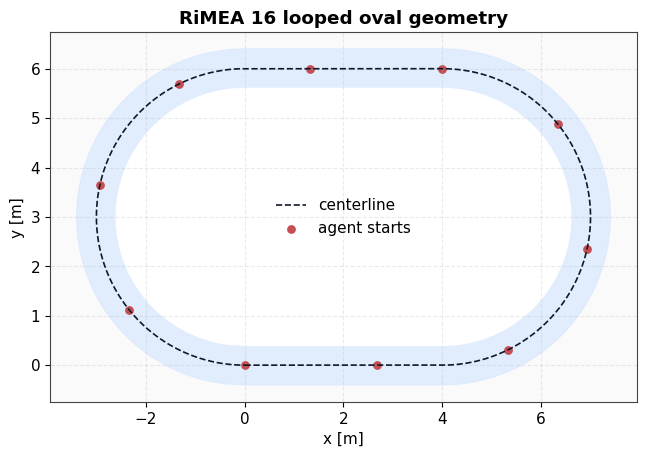

In [3]:
preview_geometry = PREVIEW_GEOMETRY
preview_fig, preview_ax = plt.subplots(figsize=(8, 4.8))
PREVIEW_SCENARIO.plot(ax=preview_ax)
x_center, y_center = preview_geometry.centerline.xy
preview_ax.plot(x_center, y_center, color="#111827", linestyle="--", linewidth=1.2, label="centerline")
positions = pd.DataFrame(preview_geometry.positions, columns=["x", "y"])
preview_ax.scatter(positions["x"], positions["y"], color="#C44E52", s=28, label="agent starts")
preview_ax.set_title("RiMEA 16 looped oval geometry")
preview_ax.legend(frameon=False)
plt.show()

## Parameter Sweep

The simulation cell is captured to suppress the shared runner's debug output.

## Measurement Method

The plotted x-axis is the **measured local density**, not just the three target density labels from the sweep.

- Density: for each frame, agent positions are projected onto the loop centerline. We compute the 1D Voronoi headway as `0.5 * distance_to_front + 0.5 * distance_to_back`, then convert it to density with `rho = 1 / headway`.
- Speed: positions are projected onto the same centerline and unwrapped over repeated laps. Speed is computed from the centerline displacement over a `10`-frame window, which is less noisy than frame-to-frame differences.
- Filtering: only samples after each agent has completed at least `3` laps are used for the speed-density analysis.
- Aggregation: the final curve uses density bins, but bins with fewer than `50` samples are dropped before plotting to avoid unstable outliers.

Because the local density varies over time and around the ring, one simulation run produces many density bins rather than a single point.

In [ ]:
%%capture
runs = {}
for params in DENSITY_CASES:
    spacing = TRACK_LENGTH / params["num_agents"]
    scenario, geometry = build_loop_scenario(
        label=f"rimea16-{params['label']}",
        desired_speed=DESIRED_SPEED,
        num_agents=params["num_agents"],
        spacing=spacing,
        max_simulation_time=180.0,
    )
    with redirect_stdout(io.StringIO()):
        result = run_scenario(scenario, seed=42)
    traj_df = result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
    samples = compute_density_speed_samples(
        trajectory_df=traj_df,
        frame_rate=result.frame_rate,
        centerline=geometry.centerline,
        track_length=geometry.track_length,
    )
    curve = compute_density_speed_curve(samples, min_samples=50)
    fit = summarize_reference_fit(curve, REFERENCE)
    lap_counts = compute_lap_counts(traj_df, geometry.centerline, geometry.track_length)
    traj = pedpy.TrajectoryData(traj_df, frame_rate=result.frame_rate)
    runs[params['label']] = {
        "params": params,
        "scenario": scenario,
        "geometry": geometry,
        "samples": samples,
        "curve": curve,
        "fit": fit,
        "lap_counts": lap_counts,
        "trajectory": traj,
        "first_frame": traj_df.loc[traj_df['frame'] == traj_df['frame'].min(), ['x', 'y']].copy(),
    }
    result.cleanup()


## Trajectories

The three density cases share the same geometry and differ only in the number of agents on the loop. Hollow circle markers highlight the first frame of the agents.

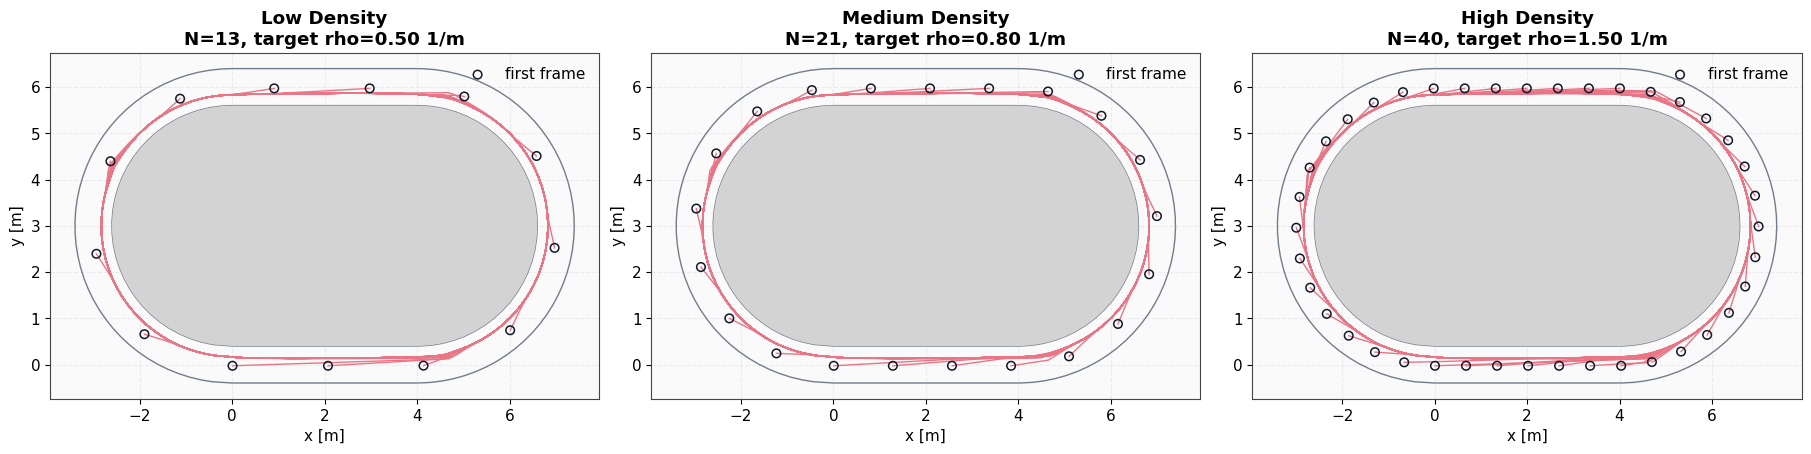

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
for ax, label in zip(axes, ["low density", "medium density", "high density"]):
    run = runs[label]
    run["scenario"].plot(ax=ax)
    pedpy.plot_trajectories(
        traj=run["trajectory"],
        walkable_area=pedpy.WalkableArea(run["scenario"].walkable_polygon),
        axes=ax,
        alpha=0.7,
        linewidth=0.8,
        color=run["params"]["color"],
    ).set_aspect("equal")
    ax.scatter(
        run["first_frame"]["x"],
        run["first_frame"]["y"],
        s=38,
        facecolors="none",
        edgecolors="#111827",
        linewidths=1.1,
        zorder=5,
        label="first frame",
    )
    ax.set_title(
        f"{label.title()}\n"
        f"N={run['params']['num_agents']}, target rho={run['params']['target_density_1pm']:.2f} 1/m"
    )
    ax.grid(alpha=0.2, linestyle="--")
    ax.legend(frameon=False, loc="upper right")
plt.show()

## Aggregated Speed-Density Curves vs Reference Percentiles

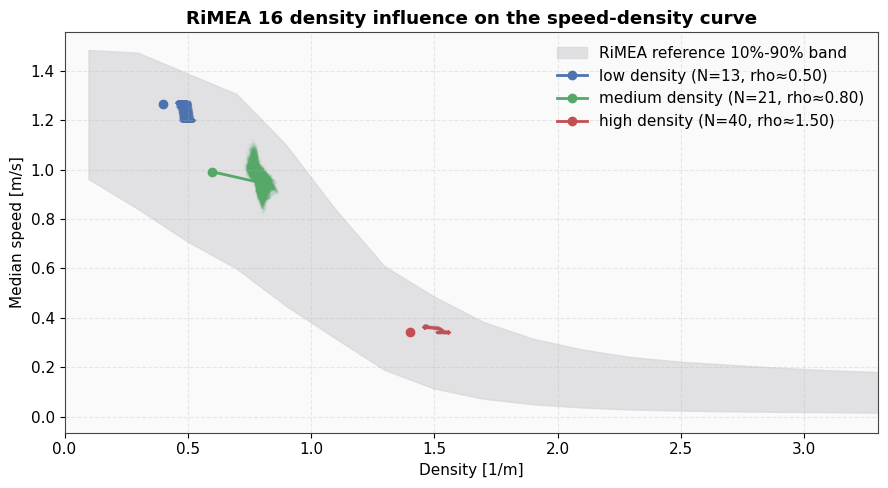

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.fill_between(
    REFERENCE["density_1pm"],
    REFERENCE["speed_p10_mps"],
    REFERENCE["speed_p90_mps"],
    color="#d4d4d8",
    alpha=0.65,
    label="RiMEA reference 10%-90% band",
)
for params in DENSITY_CASES:
    samples = runs[params['label']]["samples"]
    ax.scatter(
        samples["density_1pm"],
        samples["speed_mps"],
        s=6,
        alpha=0.06,
        color=params["color"],
        linewidths=0,
    )
    curve = runs[params['label']]["curve"]
    ax.plot(
        curve["density_1pm"],
        curve["speed_mps"],
        marker="o",
        linewidth=2,
        color=params["color"],
        label=(
            f"{params['label']} "
            f"(N={params['num_agents']}, rho≈{params['target_density_1pm']:.2f})"
        ),
    )
ax.set_title("RiMEA 16 density influence on the speed-density curve")
ax.set_xlabel("Density [1/m]")
ax.set_ylabel("Median speed [m/s]")
ax.set_xlim(0,3.3)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=False)
plt.show()

In [8]:
summary_rows = []
for params in DENSITY_CASES:
    fit = runs[params['label']]["fit"]
    summary_rows.append(
        {
            "variant": params["label"],
            "v0 [m/s]": DESIRED_SPEED,
            "target density [1/m]": round(float(params["target_density_1pm"]), 3),
            "agents": params["num_agents"],
            "agents >= 3 laps": int((runs[params['label']]["lap_counts"]["completed_laps"] >= 3).sum()),
            "min laps": int(runs[params['label']]["lap_counts"]["completed_laps"].min()),
            "mean speed [m/s]": round(float(fit["speed_mps"].mean()), 3),
            "curve bins kept": int(len(runs[params['label']]["curve"])),
            "inside band": round(float(fit["inside_band"].mean()), 3),
            "below p10": round(float(fit["below_p10"].mean()), 3),
            "above p90": round(float(fit["above_p90"].mean()), 3),
        }
    )
pd.DataFrame(summary_rows)

,variant,v0 [m/s],target density [1/m],agents,agents >= 3 laps,min laps,mean speed [m/s],curve bins kept,inside band,below p10,above p90
0,low density,1.2,0.5,13,13,8,1.267,1,1.0,0.0,0.0
1,medium density,1.2,0.8,21,21,6,0.969,2,1.0,0.0,0.0
2,high density,1.2,1.5,40,16,2,0.343,1,1.0,0.0,0.0
